# Sales


## 1.1 Business Problem

The e-commerce company has a large volume of sales data but lacks the tools to transform it into actionable business insights. This limits its ability to optimize inventory, target marketing campaigns, identify seasonal trends, and choose the best markets for expansion. The project aims to analyze sales data to identify what to sell, where to focus, when to act, and where to expand. The ultimate goal is to support faster, more informed, and data-driven business decisions.

## 1. Import libraries

In [1]:
!pip install -q -U watermark

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 21.7 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import random
import matplotlib.ticker as mticker


In [3]:
%reload_ext watermark
%watermark -a "Data Science Project"
%watermark --iversions

Author: Data Science Project

matplotlib: 3.10.0
numpy     : 2.1.3
pandas    : 2.2.3
seaborn   : 0.13.2



## 2. Generate fictional data

In [4]:
def generate_fictional_data(num_records=400):

    # Dictionary with products
    products = {
        "Laptop Pro X": {
            "Category": "Electronics",
            "Price(USD)": 899.99
        },
        "Wireless Mouse": {
            "Category": "Accessories",
            "Price(USD)": 24.99
        },
        "Mechanical Keyboard": {
            "Category": "Accessories",
            "Price(USD)": 79.99
        },
        "24-inch Monitor": {
            "Category": "Monitors",
            "Price(USD)": 249.99
        },
        "Gaming Headset": {
            "Category": "Audio",
            "Price(USD)": 69.99
        },
        "Full HD Webcam": {
            "Category": "Accessories",
            "Price(USD)": 49.99
        },
        "1TB SSD": {
            "Category": "Storage",
            "Price(USD)": 99.99
        }
    }

    # List with product names
    products_list = list(products.keys())

    # Dictionary with cities and states
    cities_states = {
        "New York": "NY",
        "Los Angeles": "CA",
        "Houston": "TX",
        "Columbus": "OH",
        "Miami": "FL",
        "Charlotte": "NC",
        "Philadelphia": "PA"
    }

    # List with city names
    cities_list = list(cities_states.keys())

    # List that will store the sales
    sales_data = []

    # Initial order date
    initial_date = datetime(2026, 3, 1)

    # Generate fictitious sales
    for i in range(num_records):
        product_name = random.choice(products_list)
        city = random.choice(cities_list)
        quantity = np.random.randint(1, 5)
        order_date = initial_date + timedelta(days=i // 5, hours=random.randint(0, 12))

        # Apply a random discount only to accessories
        if product_name == "Wireless Mouse":
            unit_price = (products[product_name]["Price(USD)"] * np.random.uniform(1.0))
        else:
            unit_price = products[product_name]["Price(USD)"]

        # Save the sales
        sales_data.append({
            "Order_ID": 100 + i,
            "Order_Date": order_date,
            "Product_Name": product_name,
            "Category": products[product_name]["Category"],
            "Unit_Price": round(unit_price, 2),
            "Quantity": quantity,
            "Customer_ID": np.random.randint(50, 140),
            "City": city,
            "State": cities_states[city]
        })

    # Return DataFrame
    return pd.DataFrame(sales_data)


# Generate the dataset
sales = generate_fictional_data()

## 3. Data Exploration

In [5]:
# Information
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order_ID      400 non-null    int64         
 1   Order_Date    400 non-null    datetime64[ns]
 2   Product_Name  400 non-null    object        
 3   Category      400 non-null    object        
 4   Unit_Price    400 non-null    float64       
 5   Quantity      400 non-null    int64         
 6   Customer_ID   400 non-null    int64         
 7   City          400 non-null    object        
 8   State         400 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 28.3+ KB


In [6]:
# Shape
sales.shape

(400, 9)

In [7]:
# First 5 rows of the dataset
sales.head()

,Order_ID,Order_Date,Product_Name,Category,Unit_Price,Quantity,Customer_ID,City,State
0,100,2026-03-01 02:00:00,Wireless Mouse,Accessories,24.99,2,61,Los Angeles,CA
1,101,2026-03-01 10:00:00,24-inch Monitor,Monitors,249.99,1,93,New York,NY
2,102,2026-03-01 06:00:00,24-inch Monitor,Monitors,249.99,2,75,Los Angeles,CA
3,103,2026-03-01 11:00:00,24-inch Monitor,Monitors,249.99,1,65,Miami,FL
4,104,2026-03-01 10:00:00,1TB SSD,Storage,99.99,1,118,Los Angeles,CA


In [8]:
# Statistics
sales.describe()

,Order_ID,Order_Date,Unit_Price,Quantity,Customer_ID
count,400.000000,400,400.000000,400.000000,400.000000
mean,299.500000,2026-04-09 18:15:45,205.640000,2.500000,94.362500
min,100.000000,2026-03-01 02:00:00,24.990000,1.000000,50.000000
25%,199.750000,2026-03-21 00:15:00,49.990000,1.000000,76.000000
50%,299.500000,2026-04-09 18:00:00,79.990000,3.000000,95.000000
75%,399.250000,2026-04-29 16:00:00,249.990000,4.000000,114.000000
max,499.000000,2026-05-19 12:00:00,899.990000,4.000000,139.000000
std,115.614301,NaN,293.469356,1.137204,24.423808


## 4. Feature engineering




In [9]:
# Revenue calculation
sales["Revenue"] = sales["Unit_Price"] * sales["Quantity"]

In [10]:
# Delivery status
sales["Delivery_Status"] = ["Fast" if state in ["New York", "Los Angeles"] else "Normal" for state in sales["State"]]

In [11]:
# Sales information
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Order_ID         400 non-null    int64         
 1   Order_Date       400 non-null    datetime64[ns]
 2   Product_Name     400 non-null    object        
 3   Category         400 non-null    object        
 4   Unit_Price       400 non-null    float64       
 5   Quantity         400 non-null    int64         
 6   Customer_ID      400 non-null    int64         
 7   City             400 non-null    object        
 8   State            400 non-null    object        
 9   Revenue          400 non-null    float64       
 10  Delivery_Status  400 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(5)
memory usage: 34.5+ KB


In [12]:
# Last 5 rows of the dataset
sales.tail()

,Order_ID,Order_Date,Product_Name,Category,Unit_Price,Quantity,Customer_ID,City,State,Revenue,Delivery_Status
395,495,2026-05-19 02:00:00,1TB SSD,Storage,99.99,4,60,Columbus,OH,399.96,Normal
396,496,2026-05-19 12:00:00,Wireless Mouse,Accessories,24.99,4,111,Philadelphia,PA,99.96,Normal
397,497,2026-05-19 03:00:00,Full HD Webcam,Accessories,49.99,3,62,Los Angeles,CA,149.97,Normal
398,498,2026-05-19 09:00:00,Wireless Mouse,Accessories,24.99,2,124,Los Angeles,CA,49.98,Normal
399,499,2026-05-19 05:00:00,Full HD Webcam,Accessories,49.99,3,59,Los Angeles,CA,149.97,Normal


# 5. Data Analysis

## Top 5 best-selling products

In [13]:
# Top 5 best-selling products
top_products = sales.groupby("Product_Name")["Quantity"].sum().sort_values(ascending=False).head(5)

In [14]:
top_products

,Quantity
Product_Name,
Wireless Mouse,202
1TB SSD,150
Laptop Pro X,142
Gaming Headset,132
Full HD Webcam,128


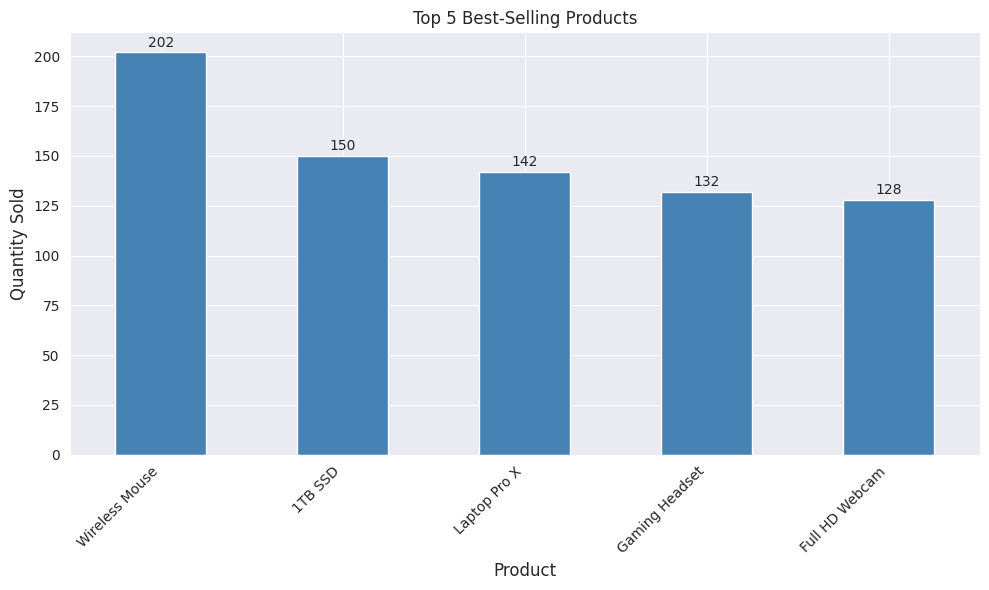

In [15]:
# Dashboard
sns.set_style("darkgrid")

plt.figure(figsize=(10, 6))

ax = top_products.sort_values(ascending=False).plot(kind="bar", color="steelblue")

ax.bar_label(ax.containers[0], padding=2)

plt.title("Top 5 Best-Selling Products")
plt.xlabel("Product", fontsize=12)
plt.ylabel("Quantity Sold", fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Monthly Revenue

In [16]:
# Month of sales
sales["Month"] = sales["Order_Date"].dt.strftime("%Y-%m")

In [17]:
sales.tail()

,Order_ID,Order_Date,Product_Name,Category,Unit_Price,Quantity,Customer_ID,City,State,Revenue,Delivery_Status,Month
395,495,2026-05-19 02:00:00,1TB SSD,Storage,99.99,4,60,Columbus,OH,399.96,Normal,2026-05
396,496,2026-05-19 12:00:00,Wireless Mouse,Accessories,24.99,4,111,Philadelphia,PA,99.96,Normal,2026-05
397,497,2026-05-19 03:00:00,Full HD Webcam,Accessories,49.99,3,62,Los Angeles,CA,149.97,Normal,2026-05
398,498,2026-05-19 09:00:00,Wireless Mouse,Accessories,24.99,2,124,Los Angeles,CA,49.98,Normal,2026-05
399,499,2026-05-19 05:00:00,Full HD Webcam,Accessories,49.99,3,59,Los Angeles,CA,149.97,Normal,2026-05


In [18]:
# Information
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Order_ID         400 non-null    int64         
 1   Order_Date       400 non-null    datetime64[ns]
 2   Product_Name     400 non-null    object        
 3   Category         400 non-null    object        
 4   Unit_Price       400 non-null    float64       
 5   Quantity         400 non-null    int64         
 6   Customer_ID      400 non-null    int64         
 7   City             400 non-null    object        
 8   State            400 non-null    object        
 9   Revenue          400 non-null    float64       
 10  Delivery_Status  400 non-null    object        
 11  Month            400 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(6)
memory usage: 37.6+ KB


In [19]:
# Montly revenue
monthly_revenue = sales.groupby("Month")["Revenue"].sum()

In [20]:
print(monthly_revenue)

Month
2026-03    82066.07
2026-04    68181.22
2026-05    53992.71
Name: Revenue, dtype: float64


In [21]:
# Revenue by month ($)
monthly_revenue.map("{:,.2f}".format)

,Revenue
Month,
2026-03,"82,066.07"
2026-04,"68,181.22"
2026-05,"53,992.71"


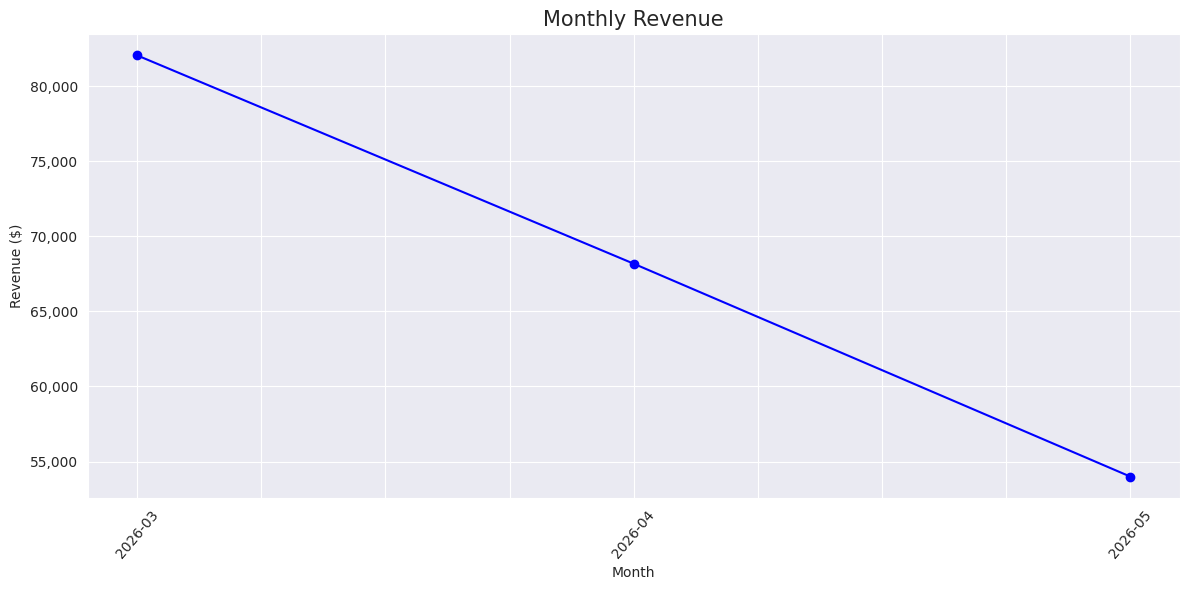

In [22]:
# Dashboard
plt.figure(figsize=(12,6))

monthly_revenue.plot(kind="line", marker="o",color="blue")

plt.title("Monthly Revenue", fontsize=15)
plt.xlabel("Month", fontsize=10)
plt.ylabel("Revenue ($)",fontsize=10)

formatter = mticker.StrMethodFormatter('{x:,.0f}')
plt.gca().yaxis.set_major_formatter(formatter)

plt.xticks(rotation=50)
plt.tight_layout()
plt.show()

## Sales per State

In [23]:
# Filtering revenue per state
sales_state = sales.groupby("State")["Revenue"].sum().sort_values(ascending=False)

In [24]:
# Revenue per state
sales_state.map("$ {:,.2f}".format)

,Revenue
State,
NC,"$ 41,088.27"
FL,"$ 34,523.42"
PA,"$ 33,928.46"
CA,"$ 26,158.41"
TX,"$ 23,488.94"
OH,"$ 23,223.70"
NY,"$ 21,828.80"


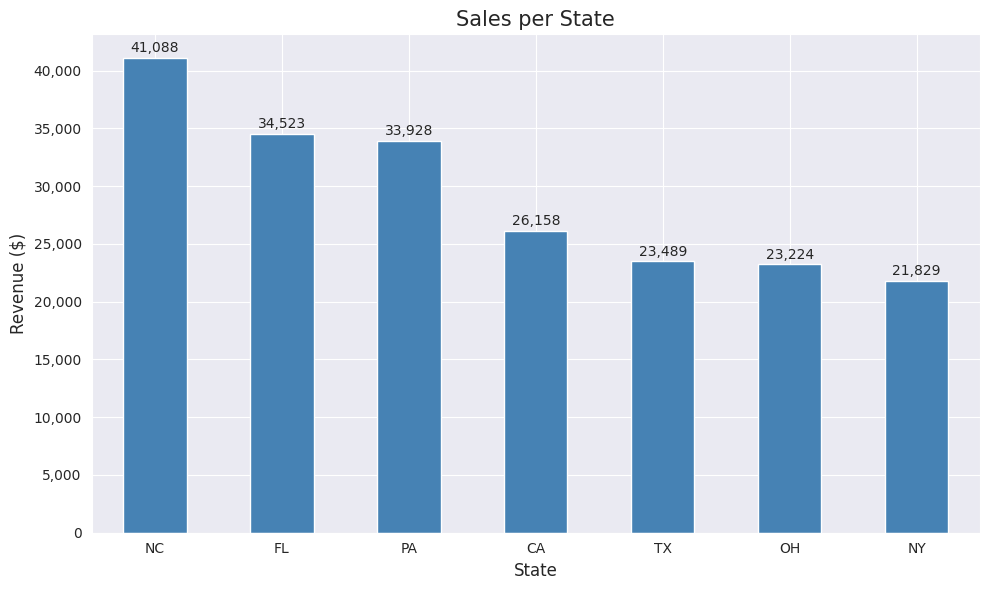

In [25]:
# Dashboard
plt.figure(figsize=(10,6))

ax2 = sales_state.plot(kind="bar", color="steelblue")
ax2.bar_label(ax2.containers[0], padding=2, fmt='{:,.0f}')

formt = mticker.StrMethodFormatter('{x:,.0f}')
plt.gca().yaxis.set_major_formatter(formt)

plt.title("Sales per State", fontsize=15)
plt.xlabel("State", fontsize=12)
plt.ylabel("Revenue ($)", fontsize=12)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Revenue per category

In [26]:
# Filtering revenue per category
revenue_category = sales.groupby("Category")["Revenue"].sum().sort_values(ascending=False)

In [27]:
revenue_category.map("$ {:,.2f}".format)

,Revenue
Category,
Electronics,"$ 127,798.58"
Monitors,"$ 30,998.76"
Accessories,"$ 21,205.48"
Storage,"$ 14,998.50"
Audio,"$ 9,238.68"


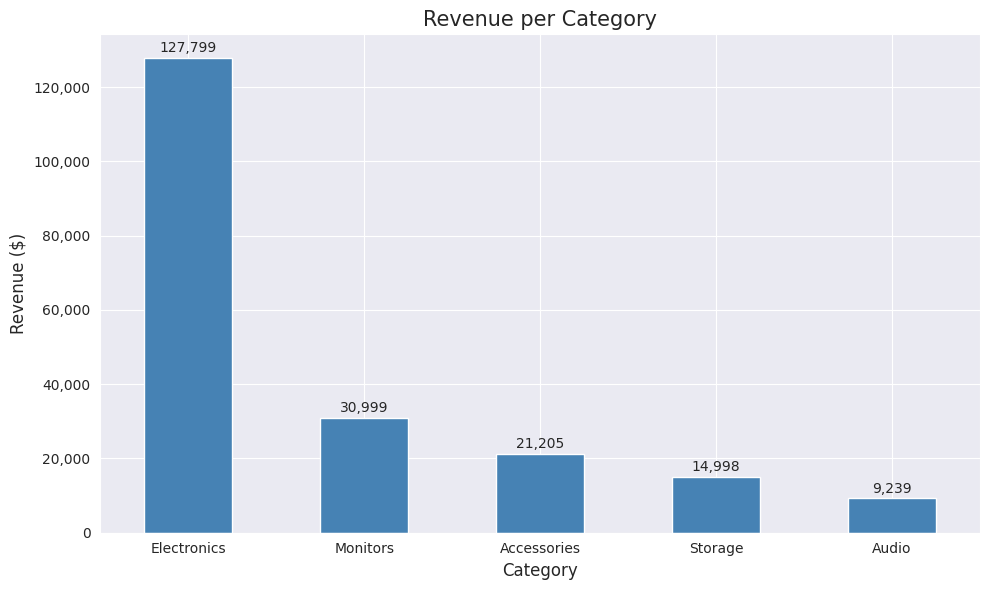

In [28]:
# Dashboard
plt.figure(figsize=(10,6))

ax3 = revenue_category.plot(kind="bar", color="steelblue")
ax3.bar_label(ax3.containers[0], padding=2, fmt='{:,.0f}')

formt = mticker.StrMethodFormatter('{x:,.0f}')
plt.gca().yaxis.set_major_formatter(formt)

plt.title("Revenue per Category", fontsize=15)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Revenue ($)", fontsize=12)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 6. Conclusion

It was observed that the **Wireless Mouse** was the best-selling product by quantity, with 202 units sold. However, the **Electronics** category generated `$127,798.58` in revenue, outperforming other categories.

From a geographical perspective, **North Carolina (NC)** leads in total revenue with `$41,088.27`, marking it as a key market. However, the general trend in monthly revenue showed a 34.21% decline between March and May 2026, dropping from `$82,066.07` to `$53,992.71`. This drop signals the need for an immediate investigation into possible causes, such as seasonal variations, increased competition, or changes in marketing effectiveness.

In short, while accessories drive sales volume, high-value electronics are the engine of our revenue. Strategic efforts should focus on boosting electronics sales, perhaps through campaigns targeting high-performing states like North Carolina, while simultaneously seeking to reverse the decline in overall monthly revenue to ensure sustainable growth and profitability.

This data-driven approach will enable the e-commerce company to make informed decisions, optimize inventory, and devise effective marketing strategies to achieve future success.